## 1) Imports

In [ ]:
# Import NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('punkt_tab')

# Import pandas
import pandas as pd

# Import seaborn
import seaborn as sns

# Import sklearn tools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Import regular expressions
import re

# Import transformer pipeline
from transformers import pipeline

# Import Matplotlib
import matplotlib.pyplot as plt

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 2) Load Spotify Song + Lyrics

(Make sure to upload "lyrics_10k.csv" to Colab default file folder "Datalab")


In [ ]:
# Load .csv file
df = pd.read_csv("lyrics_10k.csv", index_col=0)

# Peek at data
print("Columns:",df.columns)
print("Rows | Columns")
print(df.shape)
print()
print()
df.head()

Columns: Index(['song_id', 'artist_id', 'song', 'artists', 'explicit', 'genres',
       'lyrics'],
      dtype='object')
Rows | Columns
(8674, 7)




,song_id,artist_id,song,artists,explicit,genres,lyrics
0,spotify:track:1NbzT9otocflZ9d8yvA54D,spotify:artist:30TrHDLNCKQVTYWOn9QqOC,Better Than Home,['Beth Hart'],False,modern blues,Better than home Lyrics I can feel my body bre...
1,spotify:track:1crTf4RvraCjcPoqsaT9hd,spotify:artist:4P0dddbxPil35MNN9G2MEX,Illusions,['Cypress Hill'],True,chicano rap;gangster rap;hardcore hip hop;hip ...,Illusions Lyrics Some people tell me that I ne...
2,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,spotify:artist:2sG4zTOLvjKG1PSoOyf5Ej,Touching the Ground,['Brandi Carlile'],False,acoustic pop;folk;indie pop;lilith;modern folk...,Touching the Ground Lyrics I swear when we tou...
3,spotify:track:4jtIeveEJPs8SxuVa3FV21,spotify:artist:0c173mlxpT3dSFRgMO8XPh,Nothing Is Stopping You,['Big Sean'],True,detroit hip hop;hip hop;pop;pop rap;rap;southe...,Nothing Is Stopping You Lyrics Nothing is stop...
4,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,spotify:artist:4TKTii6gnOnUXQHyuo9JaD,I Shall Believe,['Sheryl Crow'],False,lilith;mellow gold;neo mellow;new wave pop;per...,I Shall Believe Lyrics Come to me now And lay ...


## 3) Clean up spreadsheet

  a. Remove unnecessary columns and empty rows

In [ ]:
# Remove supplemental columns and rows with NaN
df = df[["artists", "song", "genres", "lyrics", "song_id"]]
df = df.dropna()

# Print df to verify
print("Columns:",df.columns)
print()
print()
df.head()

Columns: Index(['artists', 'song', 'genres', 'lyrics', 'song_id'], dtype='object')




,artists,song,genres,lyrics,song_id
0,['Beth Hart'],Better Than Home,modern blues,Better than home Lyrics I can feel my body bre...,spotify:track:1NbzT9otocflZ9d8yvA54D
1,['Cypress Hill'],Illusions,chicano rap;gangster rap;hardcore hip hop;hip ...,Illusions Lyrics Some people tell me that I ne...,spotify:track:1crTf4RvraCjcPoqsaT9hd
2,['Brandi Carlile'],Touching the Ground,acoustic pop;folk;indie pop;lilith;modern folk...,Touching the Ground Lyrics I swear when we tou...,spotify:track:4AGkBc4BiGLQNBdTUmUeF3
3,['Big Sean'],Nothing Is Stopping You,detroit hip hop;hip hop;pop;pop rap;rap;southe...,Nothing Is Stopping You Lyrics Nothing is stop...,spotify:track:4jtIeveEJPs8SxuVa3FV21
4,['Sheryl Crow'],I Shall Believe,lilith;mellow gold;neo mellow;new wave pop;per...,I Shall Believe Lyrics Come to me now And lay ...,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF


b. Remove guest artists from "artists" column

In [ ]:
# Define the regex function to extract the first artist name
def get_artist(artist_entry):
    # Ensure the input is a string
    entry_str = str(artist_entry)
    # This regex looks for content within single quotes
    match = re.search(r"'([^']+)'", entry_str)
    if match:
        return match.group(1)
    # If no match or already a simple string, return the original entry
    return entry_str

# Apply the function to the 'artists' column, rename column
df['artists'] = df['artists'].apply(get_artist)
df = df.rename(columns={'artists': 'artist'})

# Reorder columns and put 'artist' as the first column
current_columns = df.columns.tolist()
current_columns.remove('artist')
final_columns = ['artist'] + current_columns
df = df[final_columns]

# Print df
df.head()

,artist,song,genres,lyrics,song_id
0,Beth Hart,Better Than Home,modern blues,Better than home Lyrics I can feel my body bre...,spotify:track:1NbzT9otocflZ9d8yvA54D
1,Cypress Hill,Illusions,chicano rap;gangster rap;hardcore hip hop;hip ...,Illusions Lyrics Some people tell me that I ne...,spotify:track:1crTf4RvraCjcPoqsaT9hd
2,Brandi Carlile,Touching the Ground,acoustic pop;folk;indie pop;lilith;modern folk...,Touching the Ground Lyrics I swear when we tou...,spotify:track:4AGkBc4BiGLQNBdTUmUeF3
3,Big Sean,Nothing Is Stopping You,detroit hip hop;hip hop;pop;pop rap;rap;southe...,Nothing Is Stopping You Lyrics Nothing is stop...,spotify:track:4jtIeveEJPs8SxuVa3FV21
4,Sheryl Crow,I Shall Believe,lilith;mellow gold;neo mellow;new wave pop;per...,I Shall Believe Lyrics Come to me now And lay ...,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF


c. Remove multiple genres, standardize to umbrella genre

In [ ]:
# Split genres
def get_main_genre(genres):
  try:
    return genres.split(";")[0]
  except:
    return "unknown"

# Get first genre entry
df["genre"] = df["genres"].apply(get_main_genre)
df = df.drop(columns=["genres"])
unique_genres = df['genre'].unique().tolist()

# Print number of unique genres and df head
print(f"Number of unique genres: {len(unique_genres)}")
df.head()

Number of unique genres: 137


,artist,song,lyrics,song_id,genre
0,Beth Hart,Better Than Home,Better than home Lyrics I can feel my body bre...,spotify:track:1NbzT9otocflZ9d8yvA54D,modern blues
1,Cypress Hill,Illusions,Illusions Lyrics Some people tell me that I ne...,spotify:track:1crTf4RvraCjcPoqsaT9hd,chicano rap
2,Brandi Carlile,Touching the Ground,Touching the Ground Lyrics I swear when we tou...,spotify:track:4AGkBc4BiGLQNBdTUmUeF3,acoustic pop
3,Big Sean,Nothing Is Stopping You,Nothing Is Stopping You Lyrics Nothing is stop...,spotify:track:4jtIeveEJPs8SxuVa3FV21,detroit hip hop
4,Sheryl Crow,I Shall Believe,I Shall Believe Lyrics Come to me now And lay ...,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF,lilith


In [ ]:
# Show counts for genres based on data
genre_counts = df['genre'].value_counts()
print("Number of instances for each genre:")
print(genre_counts)

Number of instances for each genre:
genre
album rock           589
dance pop            573
alternative metal    419
art rock             322
atl hip hop          286
                    ... 
desi pop               1
hyperpop               1
deep vocal jazz        1
deep ccm               1
disco house            1
Name: count, Length: 137, dtype: int64


In [ ]:
# Filter out genres occurring less than 40 times
genre_counts = df['genre'].value_counts()
genres_to_remove = genre_counts[genre_counts < 40].index.tolist()

# Copy old df, modify main df
df_original = df.copy()
df = df[~df['genre'].isin(genres_to_remove)].copy()

# Show original and new df shapes
print(f"Original DataFrame shape: {df_original.shape}")
print(f"Filtered DataFrame shape: {df.shape}")

Original DataFrame shape: (8613, 5)
Filtered DataFrame shape: (7548, 5)


In [ ]:
# Show counts for genres based on data
genre_counts = df['genre'].value_counts()
print("Number of instances for each genre:")
print(genre_counts)

Number of instances for each genre:
genre
album rock                   589
dance pop                    573
alternative metal            419
art rock                     322
atl hip hop                  286
detroit hip hop              278
alternative rock             264
pop                          230
art pop                      221
hip hop                      201
classic rock                 197
hard rock                    195
francoton                    167
modern rock                  163
adult standards              160
canadian contemporary r&b    143
chicano rap                  142
permanent wave               139
east coast hip hop           130
g funk                       126
conscious hip hop            118
baton rouge rap              117
glam rock                    111
chicago rap                  111
canadian pop                 110
blues rock                   108
contemporary country         102
pop rap                       95
canadian hip hop              95
l

In [ ]:
# Simplify genres and merge into umbrella genre
def simplify_genre(g):
  g = g.lower()

  if "rock" in g or "indie" in g:
    return "rock"
  elif "metal" in g:
    return "metal"
  elif "punk" in g or "permanent wave" in g:
    return "punk"
  elif "folk" in g or "lilith" in g or "singer-songwriter" in g or "singer" in g:
    return "folk"
  elif "pop" in g:
    return "pop"
  elif "r&b" in g or "funk" in g or "soul" in g:
    return "r&b"
  elif "hip hop" in g or "francoton" in g:
    return "hip hop"
  elif "rap" in g or "trap" in g:
    return "rap"
  elif "trance" in g or "dance" in g or "edm" in g or "techno" in g or "big room" in g:
    return "dance"
  elif "country" in g:
    return "country"
  elif "blues" in g or "black americana" in g:
    return "blues"
  elif "adult standards" in g:
    return "adult standards"
  else:
    return "other"

# Apply to df
df["genre"] = df["genre"].apply(simplify_genre)

# Reorder genre column
current_columns = df.columns.tolist()
current_columns.remove('genre')
lyrics_index = current_columns.index('lyrics')

# Insert 'genre' after 'song' and before 'lyrics'
new_columns = current_columns[:lyrics_index] + ['genre'] + current_columns[lyrics_index:]

df = df[new_columns]
df.head()

,artist,song,genre,lyrics,song_id
1,Cypress Hill,Illusions,rap,Illusions Lyrics Some people tell me that I ne...,spotify:track:1crTf4RvraCjcPoqsaT9hd
2,Brandi Carlile,Touching the Ground,pop,Touching the Ground Lyrics I swear when we tou...,spotify:track:4AGkBc4BiGLQNBdTUmUeF3
3,Big Sean,Nothing Is Stopping You,hip hop,Nothing Is Stopping You Lyrics Nothing is stop...,spotify:track:4jtIeveEJPs8SxuVa3FV21
4,Sheryl Crow,I Shall Believe,folk,I Shall Believe Lyrics Come to me now And lay ...,spotify:track:5Dbr7Fy5VhSTXRbt2h3EYF
5,Alice Cooper,Why Trust You,rock,Why Trust You Lyrics You come on strong with a...,spotify:track:6QhsQvMgEuqJE6z7re1ijE


In [ ]:
# Verify reduced genre amount and show instance counts
genre_counts = df['genre'].value_counts()
print(f"Number of unique genres: {df['genre'].nunique()}")
print("Number of instances for each genre:")
print(genre_counts)

Number of unique genres: 13
Number of instances for each genre:
genre
rock               2207
pop                1666
hip hop            1275
rap                 581
dance               430
metal               419
r&b                 269
country             215
adult standards     160
punk                139
folk                 93
blues                49
other                45
Name: count, dtype: int64


d) Remove songs with lyric token count <20

In [ ]:
# Show token statistics for dataset
df["token_count"] = df["lyrics"].apply(lambda x: len(word_tokenize(str(x))))
print(df["token_count"].min())
df["token_count"].describe()

6


,token_count
count,7548.000000
mean,361.027557
std,213.718674
min,6.000000
25%,220.000000
50%,308.000000
75%,444.000000
max,2577.000000


In [ ]:
# Drop short lyrics
MIN_TOKENS = 20

df = df[
    (df["token_count"] >= MIN_TOKENS)
]

print(df.shape)

(7525, 6)


## 4) Analyze Sentiment and Evaluate with Logistic Regression Classifier



In [ ]:
# Run sentiment analysis
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(str(text))["compound"]

df["sentiment"] = df["lyrics"].apply(get_sentiment)

# Display statistics for the numerical sentiment scores
print(df["sentiment"].describe())

count    7525.000000
mean        0.187267
std         0.875859
min        -0.999900
25%        -0.927400
50%         0.773900
75%         0.983500
max         0.999900
Name: sentiment, dtype: float64


In [ ]:
# Convert continuous sentiment scores to discrete labels for classification
def categorize_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    df["lyrics"], df["sentiment"], test_size=0.2, random_state=42
)

y_train_classified = y_train.apply(categorize_sentiment)
y_test_classified = y_test.apply(categorize_sentiment)

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words="english", # Remove stop words
                             max_features=5000, # Keeps only top 5,000 words
                             )

X_train_vec = vectorizer.fit_transform(X_train) # Learn from training data
X_test_vec = vectorizer.transform(X_test) # Apply to test data

# Model training with L2 regularization (penalty='l2') and stronger regularization (C=0.1)
model = LogisticRegression(class_weight="balanced", max_iter=1000, penalty='l2', C=0.1)
model.fit(X_train_vec, y_train_classified)

y_pred = model.predict(X_test_vec)

print(confusion_matrix(y_test_classified, y_pred))
print(classification_report(y_test_classified, y_pred))

[[444   8 145]
 [  2   8   1]
 [153  14 730]]
              precision    recall  f1-score   support

    negative       0.74      0.74      0.74       597
     neutral       0.27      0.73      0.39        11
    positive       0.83      0.81      0.82       897

    accuracy                           0.79      1505
   macro avg       0.61      0.76      0.65      1505
weighted avg       0.79      0.79      0.79      1505



In [ ]:
# Check for overfitting

# Transform X_train and X_test using the fitted vectorizer
X_train_transformed = vectorizer.transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

# Calculate accuracy using the transformed data and classified labels
train_accuracy = model.score(X_train_transformed, y_train_classified)
test_accuracy = model.score(X_test_transformed, y_test_classified)

print(f"Training accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")
print(f"Difference: {train_accuracy - test_accuracy}")

Training accuracy: 0.8282392026578073
Test accuracy: 0.7853820598006644
Difference: 0.042857142857142816


In [ ]:
# Save the processed sentiment DataFrame to a CSV file
df.to_csv('sentiment_lyrics.csv', index=False)
print("DataFrame 'df' saved to 'sentiment_lyrics.csv'. You can now download it from the Colab file browser.")

DataFrame 'df' saved to 'sentiment_lyrics.csv'. You can now download it from the Colab file browser.


In [ ]:
# Create a DataFrame for test results
test_results = pd.DataFrame({
    'lyrics': X_test, # Features / input data used to make predictions (song lyrics)
    'compound': y_test, # Original compound sentiment score
    'sentiment': y_test_classified, # Actual classified sentiment
    'predicted_sentiment': y_pred, # Predicted classified sentiment
})

# Join with original df to get song_id and genre
test_results = test_results.set_index(X_test.index)
original_df_subset = df.loc[X_test.index, ['song', 'genre', 'artist']]
test_results = test_results.join(original_df_subset)

# Calculate if the prediction was correct
test_results['correct'] = (test_results['sentiment'] == test_results['predicted_sentiment'])

display(test_results.head())

,lyrics,compound,sentiment,predicted_sentiment,song,genre,artist,correct
6754,Miami Vice Lyrics Encore une fois je creuse l...,-0.8402,negative,negative,Miami Vice,hip hop,GIMS,True
1648,Midnight Decisions Lyrics Remember when we had...,-0.9968,negative,negative,Midnight Decisions,dance,Sia,True
3121,Translations Português Gold Digger Lyrics She ...,0.9792,positive,negative,Gold Digger,rap,Kanye West,False
6396,Lies Lyrics Funny how you think you know a man...,-0.9994,negative,negative,Lies,country,Nikki Lane,True
4432,Translations Español Français Needed Me Lyrics...,-0.9937,negative,negative,Needed Me,pop,Rihanna,True


In [ ]:
# Show average compound sentiment score by genre as table, data from test_results
genre_results = (
    test_results.groupby("genre")
    .agg(
        songs=("song", "count"),
        accuracy=("correct", "mean"),
        avg_compound=("compound", "mean"), # Compound sentiment score
        most_common_actual=("sentiment", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan), # Actual classified sentiment
        most_common_predicted=("predicted_sentiment", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan), # Predicted classified sentiment
    )
    .sort_values(["songs", "accuracy"], ascending=[False, False])
)

display(genre_results)

,songs,accuracy,avg_compound,most_common_actual,most_common_predicted
genre,,,,,
rock,476,0.766807,0.213657,positive,positive
pop,335,0.797015,0.413037,positive,positive
hip hop,253,0.762846,-0.152017,negative,negative
rap,98,0.795918,-0.404588,negative,negative
dance,89,0.775281,0.341418,positive,positive
metal,67,0.865672,-0.106727,negative,negative
r&b,53,0.698113,0.315655,positive,positive
country,41,0.878049,0.671241,positive,positive
adult standards,32,0.875000,0.855656,positive,positive


/tmp/ipykernel_881/519393342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_plot, x="genre", y="avg_compound", palette="viridis")


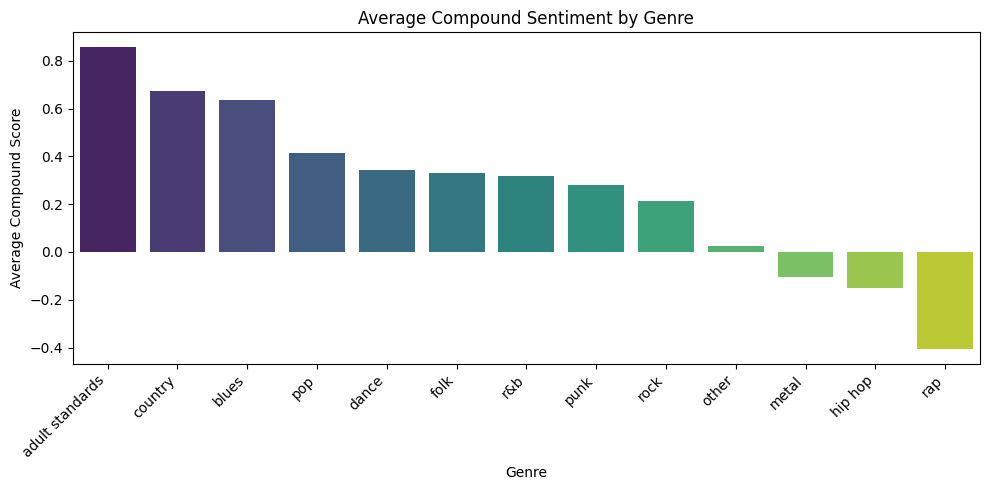

In [ ]:
# Show average compound sentiment score by genre as bar plot
plt.figure(figsize=(10, 5))
genre_plot = genre_results.sort_values("avg_compound", ascending=False).reset_index()
sns.barplot(data=genre_plot, x="genre", y="avg_compound", palette="viridis")
plt.title("Average Compound Sentiment by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Show average compound sentiment score by artist as table
artist_results = (
    test_results.groupby("artist")
    .agg(
        songs=("song", "count"),
        accuracy=("correct", "mean"),
        avg_compound=("compound", "mean"),
        most_common_actual=("sentiment", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
        most_common_predicted=("predicted_sentiment", lambda s: s.mode().iat[0] if not s.mode().empty else np.nan),
    )
    .sort_values(["songs", "accuracy"], ascending=[False, False])
)

display(artist_results)

,songs,accuracy,avg_compound,most_common_actual,most_common_predicted
artist,,,,,
Iggy Pop,35,0.771429,0.354740,positive,positive
GIMS,34,0.705882,-0.002671,positive,negative
Marilyn Manson,31,0.870968,-0.179923,negative,negative
Eminem,30,0.900000,-0.730417,negative,negative
Alice Cooper,27,0.740741,-0.033396,positive,positive
...,...,...,...,...,...
Tony Yayo,1,1.000000,-0.991600,negative,negative
k.d. lang,1,1.000000,0.993900,positive,positive
will.i.am,1,1.000000,0.997500,positive,positive


/tmp/ipykernel_881/2638544994.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=artist_plot_top, x="artist", y="avg_compound", palette="viridis")


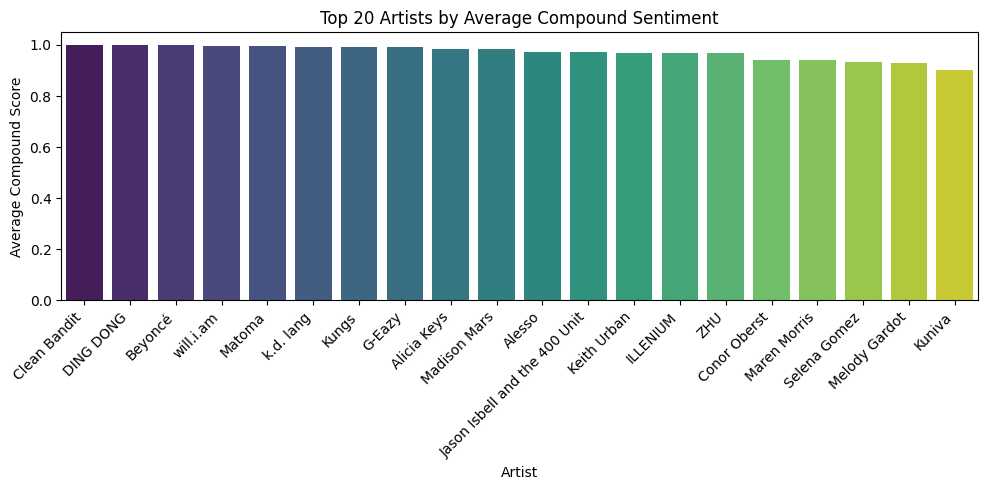

In [ ]:
# Show top positive compound sentiment score by artist as bar plot
plt.figure(figsize=(10, 5))
artist_plot_top = artist_results.sort_values("avg_compound", ascending=False).head(20).reset_index()
sns.barplot(data=artist_plot_top, x="artist", y="avg_compound", palette="viridis")
plt.title("Top 20 Artists by Average Compound Sentiment")
plt.xlabel("Artist")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_881/1096527566.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=artist_plot_bottom, x="artist", y="avg_compound", palette="magma")


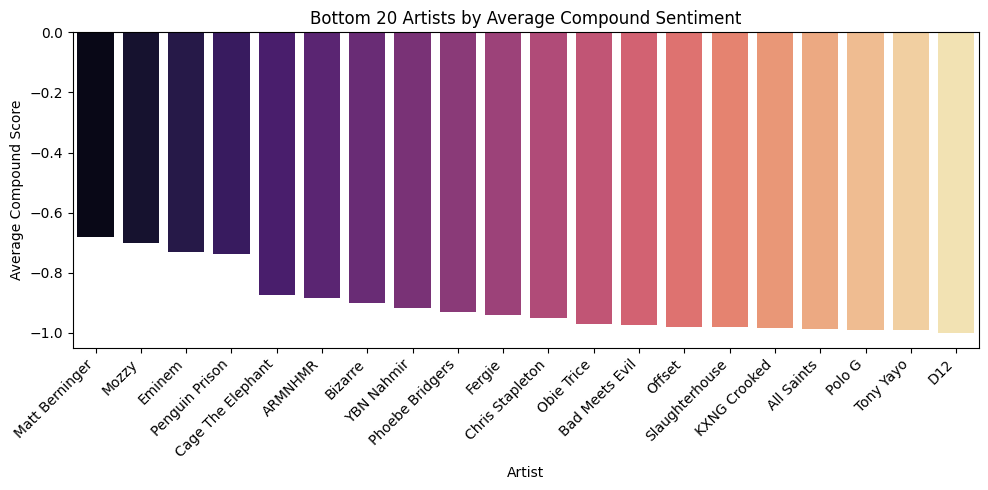

In [ ]:
# Show top negative compound sentiment score by artist as bar plot
plt.figure(figsize=(10, 5))
artist_plot_bottom = artist_results.sort_values("avg_compound", ascending=False).tail(20).reset_index()
sns.barplot(data=artist_plot_bottom, x="artist", y="avg_compound", palette="magma")
plt.title("Bottom 20 Artists by Average Compound Sentiment")
plt.xlabel("Artist")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5) Analyze Emotion

In [ ]:
# Assign sentiment degrees to sentiment scores with 9 discrete labels
def categorize_sentiment_degrees(score):
    if score <= -0.76251:
        return 'Extremely Negative'
    elif -0.76251 < score <= -0.5251:
        return 'Very Negative'
    elif -0.5251 < score <= -0.28751:
        return 'Negative'
    elif -0.28751 < score <= -0.051:
        return 'Slightly Negative'
    elif -0.051 < score < 0.051:
        return 'Neutral'
    elif 0.051 <= score < 0.28751:
        return 'Slightly Positive'
    elif 0.28751 <= score < 0.5251:
        return 'Positive'
    elif 0.5251 <= score < 0.76251:
        return 'Very Positive'
    elif score >= 0.76251:
        return 'Extremely Positive'
    else:
        return 'Undefined'

df['sentiment_degree'] = df['sentiment'].apply(categorize_sentiment_degrees)

display(df['sentiment_degree'].value_counts())

,count
sentiment_degree,
Extremely Positive,3781
Extremely Negative,2379
Very Positive,349
Very Negative,280
Positive,252
Negative,193
Slightly Negative,137
Slightly Positive,100
Neutral,54


In [ ]:
# Analyze sentiment_degree column
positive_count = df['sentiment_degree'].str.contains('positive', case=False, na=False).sum()
negative_count = df['sentiment_degree'].str.contains('negative', case=False, na=False).sum()
neutral_count = df['sentiment_degree'].str.contains('neutral', case=False, na=False).sum()

# Display results
print("Sentiment Analysis Results:")
print(f"Positive entries: {positive_count}")
print(f"Negative entries: {negative_count}")
print(f"Neutral entries: {neutral_count}")
print(f"\nTotal analyzed: {positive_count + negative_count + neutral_count}")

Sentiment Analysis Results:
Positive entries: 4482
Negative entries: 2989
Neutral entries: 54

Total analyzed: 7525


In [ ]:
# Run pre-trained DistilBERT model
classifier = pipeline("text-classification",
                      model="bhadresh-savani/distilbert-base-uncased-emotion")

df_emotion = df.sample(7525)

df_emotion["emotion"] = df_emotion["lyrics"].apply(
    lambda x: classifier(x, truncation=True, max_length=512)[0]["label"]
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Show table of emotion counts
df_emotion["emotion"].value_counts()

,count
emotion,
joy,2785
anger,1962
sadness,1863
fear,453
love,395
surprise,67


In [ ]:
# Save the processed emotion DataFrame to a CSV file
df_emotion.to_csv('emotion_lyrics.csv', index=False)
print("DataFrame 'df_emotion' saved to 'emotion_lyrics.csv'. You can now download it from the Colab file browser.")

DataFrame 'df_emotion' saved to 'emotion_lyrics.csv'. You can now download it from the Colab file browser.


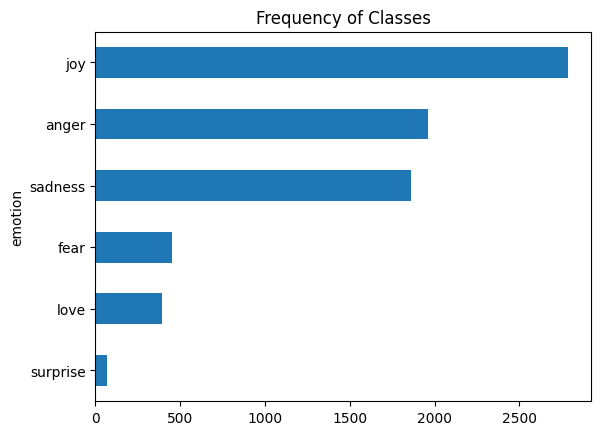

In [ ]:
# Visualize emotions as bar graph
df_emotion["emotion"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of Classes")
plt.show()

In [ ]:
# Move 'song_id' to the rightmost position
current_columns = df_emotion.columns.tolist()
if 'song_id' in current_columns:
    current_columns.remove('song_id')
    current_columns.append('song_id')
df_emotion = df_emotion[current_columns]

display(df_emotion.head())

,artist,song,genre,lyrics,token_count,sentiment,sentiment_degree,emotion,song_id
6290,Jason Isbell and the 400 Unit,Good,country,Good Lyrics You better watch yourself this tim...,296,-0.4756,Negative,fear,spotify:track:5DYoJsB936G4DGdqGn3SqT
6237,Colbie Caillat,Silver Bells,pop,Silver Bells Lyrics City side-walks busy side...,159,0.9468,Extremely Positive,joy,spotify:track:0NEgLnbi5sml6VBUcyCsXC
8183,The Killers,Losing Touch,rock,Losing Touch Lyrics Console me in my darkest h...,234,-0.4272,Negative,sadness,spotify:track:7JdTpfuh8qw4SefrSLnswk
7176,KXNG Crooked,You Busta,rap,You Busta Lyrics My Brother Dizz Made This Whe...,503,-0.6829,Very Negative,joy,spotify:track:5hBxByaSLtA2aeC2s4MeEw
8619,Megadeth,The Threat Is Real,metal,The Threat Is Real Lyrics Justified obliterati...,185,-0.9954,Extremely Negative,anger,spotify:track:1utn9T9RZCalaMH1lZt5sX


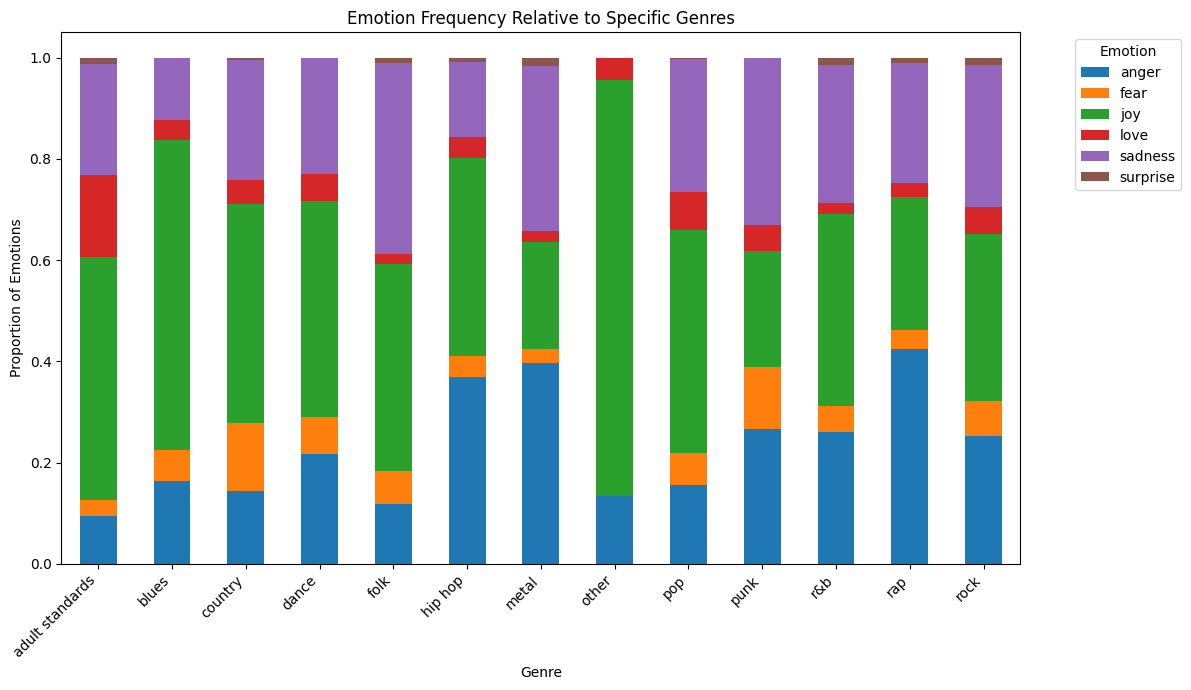

In [ ]:
# Calculate the frequency of each emotion within each genre
emotion_genre_counts = df_emotion.groupby('genre')['emotion'].value_counts(normalize=True).unstack(fill_value=0)

# Plotting the stacked bar chart
emotion_genre_counts.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Emotion Frequency Relative to Specific Genres')
plt.xlabel('Genre')
plt.ylabel('Proportion of Emotions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#@title Enter an artist's name to see their sentiment analysis
artist_name = "Taylor Swift" #@param {type:"string"}

# Filter artist_results for the specified artist
single_artist_results = artist_results[artist_results.index.str.lower() == artist_name.lower()]

if not single_artist_results.empty:
    display(single_artist_results)
else:
    print(f"No results found for artist: {artist_name}")

print()
print()

if not single_artist_results.empty:
    artist_songs_df = df_emotion[df_emotion['artist'].str.lower() == artist_name.lower()][['song', 'genre', 'sentiment_degree', 'emotion']]
    display(artist_songs_df)
else:
    print(f"No songs found for artist: {artist_name} in the dataset.")

,songs,accuracy,avg_compound,most_common_actual,most_common_predicted
artist,,,,,
Taylor Swift,18,0.722222,0.105367,positive,positive


,song,genre,sentiment_degree,emotion
433,Our Song,pop,Extremely Positive,anger
1237,Sad Beautiful Tragic,pop,Extremely Positive,joy
2781,Enchanted,pop,Extremely Positive,joy
4802,The Lucky One,pop,Extremely Positive,joy
7776,Mine,pop,Extremely Positive,anger
...,...,...,...,...
6299,Shake It Off,pop,Extremely Negative,joy
415,Lavender Haze,pop,Extremely Negative,fear
1208,Midnight Rain,pop,Extremely Positive,sadness
1456,gold rush,pop,Extremely Positive,joy


## 6) Random Spotify Playlist Generator

Use the function below to create a random 20-song playlist based on:

- emotion only
- emotion and genre together

Each run samples a new playlist from the matching songs. The output includes Spotify track IDs from `song_id`, which you can use when preparing an import file.

In [ ]:
PLAYLIST_COLUMNS = [col for col in ["song_id", "song", "artist", "genre", "sentiment", "emotion", "emotion_score"] if col in df_emotion.columns]


def generate_playlist(data, emotion=None, genre=None, playlist_size=20, random_state=None):
    df_playlist = data.copy()

    if emotion is not None:
        emotion = emotion.strip().lower()
        valid_emotions = sorted(df_playlist["emotion"].dropna().str.lower().unique())
        if emotion not in valid_emotions:
            raise ValueError(f"Invalid emotion '{emotion}'. Choose from: {valid_emotions}")
        df_playlist = df_playlist[df_playlist["emotion"].str.lower() == emotion]

    if genre is not None:
        genre = genre.strip().lower()
        valid_genres = sorted(df_playlist["genre"].dropna().str.lower().unique())
        if genre not in valid_genres:
            raise ValueError(f"Invalid genre '{genre}'. Choose from: {valid_genres}")
        df_playlist = df_playlist[df_playlist["genre"].str.lower() == genre]

    available = len(df_playlist)
    if available == 0:
        raise ValueError("No songs match the selected filters.")

    sample_size = min(playlist_size, available)
    sampled = df_playlist.sample(n=sample_size, replace=False, random_state=random_state).reset_index(drop=True)
    sampled.insert(0, "playlist_order", range(1, len(sampled) + 1))
    return sampled[ ["playlist_order"] + PLAYLIST_COLUMNS ]


def save_playlist_csv(playlist, filename="spotify_playlist_import.csv"):
    export_df = playlist.copy()
    if "song_id" in export_df.columns:
        export_df = export_df.rename(columns={"song_id": "spotify_track_uri"})
    export_df.to_csv(filename, index=False)
    print("Playlist saved to 'spotify_playlist_import.csv'. You can now download it from the Colab file browser.")
    return export_df


print("Available emotions:", sorted(df_emotion["emotion"].dropna().unique().tolist()))
print("Available genres:", sorted(df_emotion["genre"].dropna().unique().tolist()))

Available emotions: ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Available genres: ['adult standards', 'blues', 'country', 'dance', 'folk', 'hip hop', 'metal', 'other', 'pop', 'punk', 'r&b', 'rap', 'rock']


In [ ]:

# Example 1: playlist by emotion
playlist_by_emotion = generate_playlist(df_emotion, emotion="joy")
display(playlist_by_emotion)
spotify_import_df = save_playlist_csv(playlist_by_emotion, "spotify_playlist_import.csv")

'''
# Example 2: playlist by emotion + genre. Save the currently selected playlist for import into Spotify workflows.
playlist_by_both = generate_playlist(df_emotion, emotion="anger", genre="rap")
display(playlist_by_both)
spotify_import_df = save_playlist_csv(playlist_by_both, "spotify_playlist_import.csv")
'''

# Display output file
print()
print("Output file preview:")
display(spotify_import_df.head())

,playlist_order,song_id,song,artist,genre,sentiment,emotion
0,1,spotify:track:5yKG4Sa9UTlvXr3Y9Zurtu,Butterfly,BTS,pop,0.9514,joy
1,2,spotify:track:3NHxCwd9jCOzdIYKa5y7Zn,Tobia,Zucchero,pop,0.9929,joy
2,3,spotify:track:3zZl8eEazg9rs9VpgFT5lP,Let Somebody Go,Coldplay,punk,0.9496,joy
3,4,spotify:track:0xPs41EowJNEOtSLg9pGfj,Grosse bleta,GIMS,hip hop,0.2593,joy
4,5,spotify:track:1QzC4y8h6WFxHE4KlokhVr,Already Won,Kehlani,pop,0.9982,joy
5,6,spotify:track:03EZ70uDIY8IiVgWj4chnq,Cruel World,Lana Del Rey,pop,0.9940,joy
6,7,spotify:track:127IjU4PRiGTbFm2xPXLTn,Fortnight,Polo G,rap,0.9887,joy
7,8,spotify:track:2fSMyiDvsBY2glgLp00auU,Lighters,Eminem,hip hop,-0.9906,joy
8,9,spotify:track:1MxSmxgQJntfJnsZjrmXLV,Lover Undercover,Melody Gardot,adult standards,0.9895,joy
9,10,spotify:track:3QWAuUWZhvAJT1IbO99a17,Come And Stay With Me,Marianne Faithfull,rock,0.9748,joy


Playlist saved to 'spotify_playlist_import.csv'. You can now download it from the Colab file browser.

Output file preview:


,playlist_order,spotify_track_uri,song,artist,genre,sentiment,emotion
0,1,spotify:track:5yKG4Sa9UTlvXr3Y9Zurtu,Butterfly,BTS,pop,0.9514,joy
1,2,spotify:track:3NHxCwd9jCOzdIYKa5y7Zn,Tobia,Zucchero,pop,0.9929,joy
2,3,spotify:track:3zZl8eEazg9rs9VpgFT5lP,Let Somebody Go,Coldplay,punk,0.9496,joy
3,4,spotify:track:0xPs41EowJNEOtSLg9pGfj,Grosse bleta,GIMS,hip hop,0.2593,joy
4,5,spotify:track:1QzC4y8h6WFxHE4KlokhVr,Already Won,Kehlani,pop,0.9982,joy


1. Open your CSV in a spreadsheet program (Excel, Google Sheets, etc.).
2. Copy the entire spotify_track_uri column (just the URIs, one per line).
3. Open the Spotify desktop app (this works best on desktop; mobile is limited).
4. Create a new playlist (or open an existing empty one).
5. Click anywhere inside the playlist area (make sure the search bar is not active).
6. Paste the list (Ctrl + V on Windows or Cmd + V on Mac).